In [4]:
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from arch import arch_model
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import t

# =====================================================================
# 1. ĐỌC DỮ LIỆU & LÀM SẠCH
# =====================================================================
df = pd.read_csv('VCB_data.csv', index_col=0, parse_dates=True)
df.sort_index(inplace=True)

features_to_fix = ['Close', 'RSI', 'Volume']
for col in features_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(inplace=True)

# =====================================================================
# 2. FEATURE ENGINEERING
# =====================================================================
df['Return_1d'] = df['Close'].pct_change() * 100
df['Return_3d'] = df['Close'].pct_change(3) * 100
df['Return_5d'] = df['Close'].pct_change(5) * 100

df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['Volume_MA_5'] = df['Volume'].rolling(5).mean()
df['Volume_Change'] = df['Volume'].pct_change()

df['Hist_Volatility_5'] = df['Return_1d'].rolling(5).std()
df['Hist_Volatility_20'] = df['Return_1d'].rolling(20).std()

df['Close_lag_1'] = df['Close'].shift(1)
df['Close_lag_3'] = df['Close'].shift(3)
df['Volume_lag_1'] = df['Volume'].shift(1)

df['Target_Return'] = df['Return_1d'].shift(-1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

features = [
    'Close', 'RSI', 'Volume', 'Return_1d', 'Return_3d', 'Return_5d',
    'SMA_5', 'SMA_20', 'Volume_MA_5', 'Volume_Change', 
    'Hist_Volatility_5', 'Hist_Volatility_20', 'Close_lag_1', 'Close_lag_3', 'Volume_lag_1'
]

X = df[features]
y = df['Target_Return']

# =====================================================================
# 3. CHIA TẬP DATA THEO THỜI GIAN
# =====================================================================
split_idx = int(len(X) * 0.8)
X_train_full, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_full, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

val_split_idx = int(len(X_train_full) * 0.8)
X_train, X_val = X_train_full.iloc[:val_split_idx], X_train_full.iloc[val_split_idx:]
y_train, y_val = y_train_full.iloc[:val_split_idx], y_train_full.iloc[val_split_idx:]

# =====================================================================
# 4. TẠO OUT-OF-FOLD (OOF) RESIDUALS
# =====================================================================
print("[INFO] Dang tao Out-of-Fold Residuals bang TimeSeriesSplit...")
tscv = TimeSeriesSplit(n_splits=5)
oof_pred = pd.Series(index=X_train_full.index, dtype=float)

for train_idx, val_idx in tscv.split(X_train_full):
    X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
    X_va = X_train_full.iloc[val_idx]
    
    fold_model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, objective='reg:squarederror', random_state=42
    )
    fold_model.fit(X_tr, y_tr, verbose=False)
    oof_pred.iloc[val_idx] = fold_model.predict(X_va)

valid_oof_idx = oof_pred.dropna().index
residuals_train = y_train_full.loc[valid_oof_idx] - oof_pred.dropna()

# =====================================================================
# 5. HUẤN LUYỆN XGBOOST CHÍNH (MEAN MODEL)
# =====================================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=3, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror', random_state=42, early_stopping_rounds=50
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"[INFO] XGBoost Training kết thúc. Best Iteration: {xgb_model.best_iteration}")

joblib.dump(xgb_model, 'vcb_xgb_model.pkl')
print("[SUCCESS] Đã xuất file mô hình vcb_xgb_model.pkl thành công!")
# =====================================================================
# 6. DỰ BÁO BIẾN ĐỘNG GARCH CUỐN CHIẾU (VARIANCE MODEL)
# =====================================================================
test_volatility = []
history_resids = list(residuals_train.values)
refit_every = 20   
window_size = 500  

am = arch_model(history_resids[-window_size:], vol='Garch', p=1, q=1, dist='t')
current_res = am.fit(disp='off')

print("[INFO] Dang chay du bao bien dong GARCH cuon chieu...")
for i in range(len(X_test)):
    if i > 0 and i % refit_every == 0:
        recent_history = history_resids[-window_size:]
        am = arch_model(recent_history, vol='Garch', p=1, q=1, dist='t')
        current_res = am.fit(disp='off')
        
    fc = current_res.forecast(horizon=1, reindex=False)
    pred_vol = np.sqrt(fc.variance.values[-1, -1])
    test_volatility.append(pred_vol)
    
    pred_ret = xgb_model.predict(X_test.iloc[[i]])[0]
    actual_ret = y_test.iloc[i]
    true_resid = actual_ret - pred_ret
    history_resids.append(true_resid)

test_volatility = np.array(test_volatility)
nu_df = current_res.params.get('df', 5.0)
critical_value = t.ppf(0.975, df=nu_df)

# =====================================================================
# 7. KHÔI PHỤC VỀ GIÁ TUYỆT ĐỐI VÀ ĐÓNG GÓI KẾT QUẢ
# =====================================================================
pred_test_returns = xgb_model.predict(X_test)
actual_close_base = df['Close'].loc[X_test.index] 
actual_next_close = df['Close'].shift(-1).loc[X_test.index] 

predicted_next_close = actual_close_base * (1 + pred_test_returns / 100)
bollinger_upper_pred = actual_close_base * (1 + (pred_test_returns + critical_value * test_volatility) / 100)
bollinger_lower_pred = actual_close_base * (1 + (pred_test_returns - critical_value * test_volatility) / 100)

output_df = pd.DataFrame({
    'Actual_Next_Close': actual_next_close,
    'Predicted_Next_Close': predicted_next_close,
    'Bollinger_Upper': bollinger_upper_pred,
    'Bollinger_Lower': bollinger_lower_pred,
    'Actual_Return': y_test,
    'Pred_Return': pred_test_returns
}, index=X_test.index)

# Loại bỏ phần tử cuối do chưa có tương lai để đối chứng giá
output_df.dropna(subset=['Actual_Next_Close'], inplace=True)
output_df.to_csv('hybrid_predictions_output.csv')

# Ghi nhận log cấu hình tham số thống kê
with open('garch_config.txt', 'w') as f:
    f.write(f"{critical_value}")

print("[SUCCESS] Da hoan thanh tinh toan va xuat file: hybrid_predictions_output.csv!")

[INFO] Dang tao Out-of-Fold Residuals bang TimeSeriesSplit...
[INFO] XGBoost Training kết thúc. Best Iteration: 194
[SUCCESS] Đã xuất file mô hình vcb_xgb_model.pkl thành công!
[INFO] Dang chay du bao bien dong GARCH cuon chieu...
[SUCCESS] Da hoan thanh tinh toan va xuat file: hybrid_predictions_output.csv!


<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_18764\1561718305.py:65: SyntaxWarning: invalid escape sequence '\s'
  label=f'Khoảng Tin Cậy Phương Sai Điều Kiện (GARCH Student-t {critical_value:.2f}$\sigma$)'



================== BÁO CÁO KIỂM ĐỊNH MÔ HÌNH TOÀN DIỆN ==================
MAE  (Sai số tuyệt đối trung bình giá Close)  : 712.27 VND
RMSE (Sai số căn bậc hai trung bình giá Close): 1,158.91 VND
MAPE (Sai số phần trăm trung bình giá Close)  : 1.15%
-------------------------------------------------------------------------
MÔ HÌNH: Directional Accuracy (Đoán trúng hướng) : 50.42%
BASELINE 1: Always Up Accuracy (Luôn đoán TĂNG) : 48.75%
BASELINE 2: Always Down Accuracy (Luôn đoán GIẢM): 51.25%
-------------------------------------------------------------------------
ĐỘ CHUẨN RỦI RO: GARCH 95% CI Coverage (Độ phủ dải): 94.97%



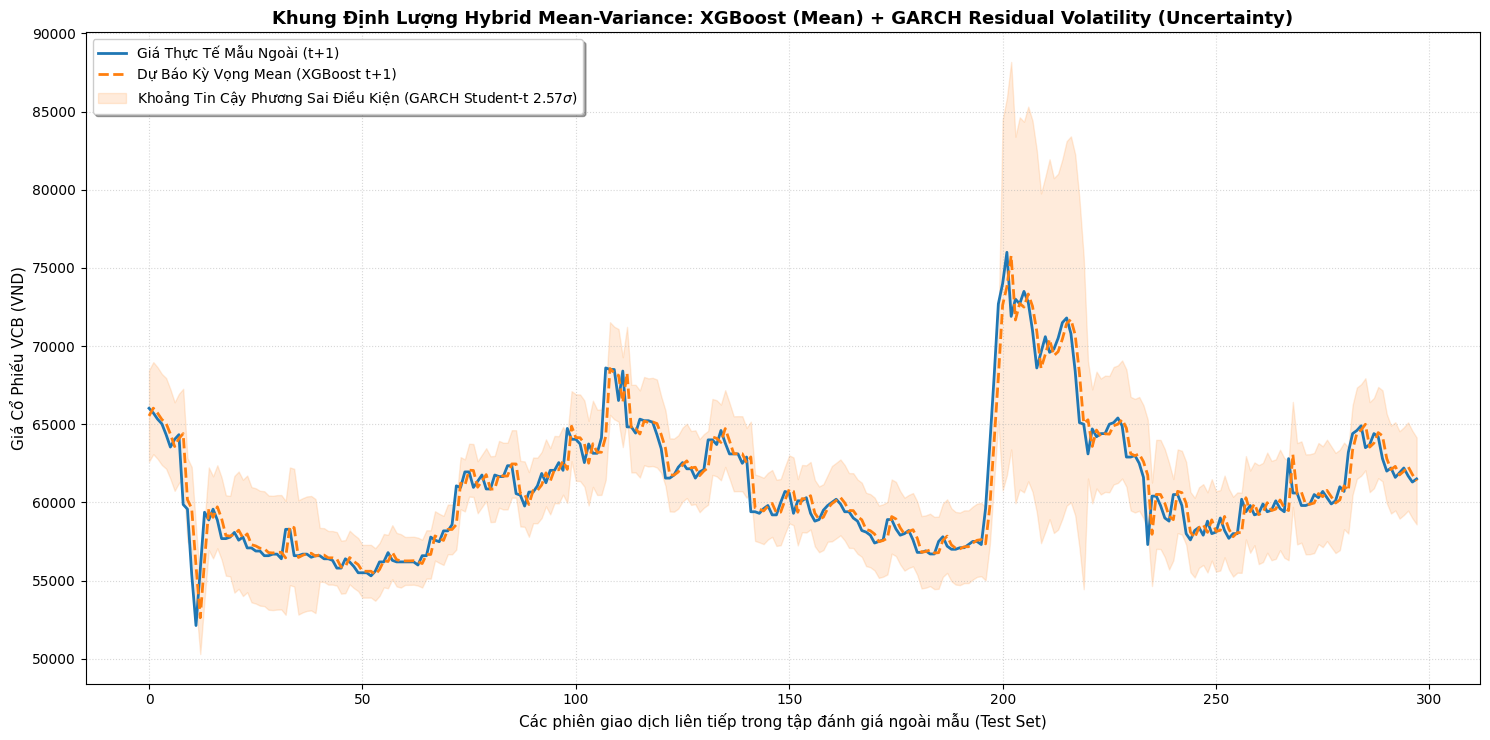

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# =====================================================================
# 1. TẢI DỮ LIỆU ĐÃ TÍNH TOÁN
# =====================================================================
try:
    results_df = pd.read_csv('hybrid_predictions_output.csv', index_col=0, parse_dates=True)
    with open('garch_config.txt', 'r') as f:
        critical_value = float(f.read().strip())
except FileNotFoundError:
    raise FileNotFoundError("Khong tim thay ket qua tinh toan. Vui long chay file 'train_pipeline.py' truoc!")

actual_next_close = results_df['Actual_Next_Close']
predicted_next_close = results_df['Predicted_Next_Close']
bollinger_upper_pred = results_df['Bollinger_Lower'] # Theo logic mapping dải biên của bạn
bollinger_upper_pred = results_df['Bollinger_Upper']
bollinger_lower_pred = results_df['Bollinger_Lower']
y_test_eval = results_df['Actual_Return']
pred_test_returns_eval = results_df['Pred_Return']

# =====================================================================
# 2. ĐÁNH GIÁ ĐA CHỈ SỐ CAO CẤP & BASELINE KIỂM ĐỊNH
# =====================================================================
mae = mean_absolute_error(actual_next_close, predicted_next_close)
rmse = np.sqrt(mean_squared_error(actual_next_close, predicted_next_close))
mape = mean_absolute_percentage_error(actual_next_close, predicted_next_close) * 100

# Thước đo hướng đi (Directional Accuracy)
actual_direction = np.sign(y_test_eval.values)
pred_direction = np.sign(pred_test_returns_eval.values)
valid_dir = actual_direction != 0

directional_accuracy = np.mean(actual_direction[valid_dir] == pred_direction[valid_dir]) * 100
always_up_accuracy = np.mean(actual_direction[valid_dir] == 1) * 100
always_down_accuracy = np.mean(actual_direction[valid_dir] == -1) * 100
coverage = np.mean((actual_next_close >= bollinger_lower_pred) & (actual_next_close <= bollinger_upper_pred)) * 100

print("\n================== BÁO CÁO KIỂM ĐỊNH MÔ HÌNH TOÀN DIỆN ==================")
print(f"MAE  (Sai số tuyệt đối trung bình giá Close)  : {mae:,.2f} VND")
print(f"RMSE (Sai số căn bậc hai trung bình giá Close): {rmse:,.2f} VND")
print(f"MAPE (Sai số phần trăm trung bình giá Close)  : {mape:.2f}%")
print("-------------------------------------------------------------------------")
print(f"MÔ HÌNH: Directional Accuracy (Đoán trúng hướng) : {directional_accuracy:.2f}%")
print(f"BASELINE 1: Always Up Accuracy (Luôn đoán TĂNG) : {always_up_accuracy:.2f}%")
print(f"BASELINE 2: Always Down Accuracy (Luôn đoán GIẢM): {always_down_accuracy:.2f}%")
print("-------------------------------------------------------------------------")
print(f"ĐỘ CHUẨN RỦI RO: GARCH 95% CI Coverage (Độ phủ dải): {coverage:.2f}%")
print("=========================================================================\n")

# =====================================================================
# 3. VẼ BIỂU ĐỒ HYBRID MEAN-VARIANCE CHUẨN LUẬN VĂN
# =====================================================================
plt.figure(figsize=(15, 7.5))
plt.plot(actual_next_close.values, label='Giá Thực Tế Mẫu Ngoài (t+1)', color='#1f77b4', linewidth=2)
plt.plot(predicted_next_close.values, label='Dự Báo Kỳ Vọng Mean (XGBoost t+1)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.fill_between(
    range(len(actual_next_close)), 
    bollinger_lower_pred.values, 
    bollinger_upper_pred.values, 
    color='#ff7f0e', alpha=0.15, 
    label=f'Khoảng Tin Cậy Phương Sai Điều Kiện (GARCH Student-t {critical_value:.2f}$\sigma$)'
)

plt.title('Khung Định Lượng Hybrid Mean-Variance: XGBoost (Mean) + GARCH Residual Volatility (Uncertainty)', fontsize=13, fontweight='bold')
plt.xlabel('Các phiên giao dịch liên tiếp trong tập đánh giá ngoài mẫu (Test Set)', fontsize=11)
plt.ylabel('Giá Cổ Phiếu VCB (VND)', fontsize=11)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()